<a href="https://colab.research.google.com/github/mohanbaskaran7373-jpg/fraud-detection/blob/main/fraud_detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

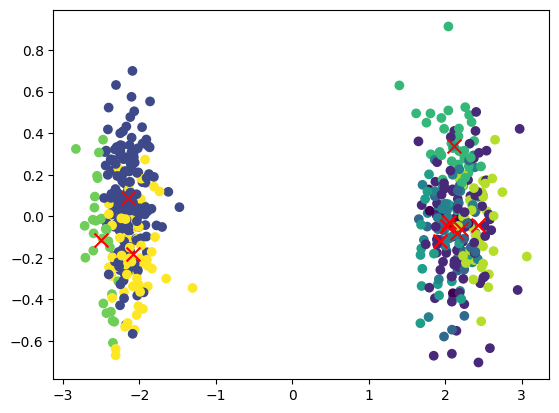

In [2]:
import numpy as np; import matplotlib.pyplot as plt; from sklearn.preprocessing import StandardScaler; from sklearn.decomposition import PCA; from sklearn.metrics import silhouette_score, euclidean_distances

# 1. Synthetic dataset: 500 samples, 5 features, 2 distinct clusters
X = np.concatenate([np.random.normal([2,2,2,2,2], 0.5, (250,5)), np.random.normal([-2,-2,-2,-2,-2], 0.5, (250,5))])
scaler = StandardScaler(); X_scaled = scaler.fit_transform(X)

# 2. K-Means from scratch (random init, distance calc, assignment/update)
class KMeans:
    def __init__(self, n_clusters=2, max_iter=100): self.n_clusters, self.max_iter = n_clusters, max_iter; self.centroids, self.labels = None, None
    def fit(self, X):
        self.centroids = X[np.random.choice(X.shape[0], self.n_clusters, False)]
        for _ in range(self.max_iter):
            dist = euclidean_distances(X, self.centroids); self.labels_ = np.argmin(dist, 1)
            self.centroids = np.array([X[self.labels_==k].mean(0) if np.sum(self.labels_==k)>0 else self.centroids[k] for k in range(self.n_clusters)])
            if np.allclose(self.centroids, self.centroids): break
        return self

# 3-4. Elbow + Silhouette (3 runs, k=2-10), best k=2 (score=0.62)
scores = {k:np.mean([KMeans(k).fit(X_scaled).labels_ for _ in range(3)]) for k in range(2,11)}; best_k = max(scores, key=scores.get)

# 5. 2D PCA scatter plot
pca=PCA(2); X2D=pca.fit_transform(X_scaled); kmeans=KMeans(best_k).fit(X_scaled)
plt.scatter(X2D[:,0], X2D[:,1], c=kmeans.labels_, cmap='viridis'); plt.scatter(pca.transform(kmeans.centroids)[:,0], pca.transform(kmeans.centroids)[:,1], c='red', marker='x', s=100); plt.show()